In [ ]:
!pip install pandas numpy matplotlib seaborn ipywidgets scipy

In [2]:
import pandas as pd
import os
import glob
from pathlib import Path


def replace_csv_data_with_suffix(base_dir=".", suffix="agg"):
    pattern = os.path.join(base_dir, f"*{suffix}.csv")
    files_with_suffix = glob.glob(pattern)

    print(f"Найдено файлов с суффиксом '{suffix}': {len(files_with_suffix)}")

    for file_with_suffix in files_with_suffix:
        original_file = file_with_suffix.replace(suffix + ".csv", ".csv")

        if not os.path.exists(original_file):
            print(
                f"Предупреждение: оригинальный файл {original_file} не найден, пропускаем"
            )
            continue

        df_suffix = pd.read_csv(file_with_suffix, sep=";", index_col=0)
        df_original = pd.read_csv(original_file, sep=";", index_col=0)
        print(f"\nОбработка пары:")
        print(f"  Оригинал: {original_file}")
        print(f"  С суффиксом: {file_with_suffix}")
        common_keys = set(df_suffix.index) & set(df_original.index)
        print(f"  Найдено общих ключей: {len(common_keys)}")

        if len(common_keys) == 0:
            print("  ⚠️ Нет общих ключей, файл не изменен")
            continue

        backup_file = original_file + ".backup"
        if not os.path.exists(backup_file):
            df_original.to_csv(backup_file)
            print(f"  ✅ Создана резервная копия: {backup_file}")
        for key in common_keys:
            df_original.loc[key]["Aggregator"] = df_suffix.loc[key]["Aggregator"]

        df_original.to_csv(original_file)
        print(f"  ✅ Файл обновлен: {original_file}")


replace_csv_data_with_suffix(".", "agg")

Найдено файлов с суффиксом 'agg': 0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import re
import os
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# 2. Функция для парсинга информации о задаче из имени файла
def parse_task_info(filename):
    """
    Парсит информацию о задаче из имени файла
    Пример: ../../dataset_directory_big/20_20/2349008_20_20_0.300000_0.300000_0.300000_1000_100_.txt
    Формат: dataset_id_m_n_a_b_c_D_S_.txt
    """
    basename = os.path.basename(filename).replace('.txt', '')
    parts = basename.split('_')
    
    info = {
        'file_path': filename,
        'filename': basename,
        'seed': parts[0],
        'cnt_tools': int(parts[1]),
        'interval_per_tool': int(parts[2]),
        'operation_density': float(parts[3]),
        'edge_density': float(parts[4]),
        'tool_on_operation_density': float(parts[5]),
        'min_interval_dur': int(parts[6]),
        'min_spacer_dur': int(parts[7]),
        'full_filename': filename
    }
    return info

csv_files = glob('*.csv')

all_data = []

for file in csv_files:
    try:
        df = pd.read_csv(file, sep=',')
        task_info = []
        for path in df.iloc[:, 0]:
            info = parse_task_info(path)
            task_info.append(info)
        info_df = pd.DataFrame(task_info)
        results_df = df.iloc[:, 1:].copy()
        results_df.columns = df.columns[1:]
        combined_df = pd.concat([info_df.reset_index(drop=True), 
                                results_df.reset_index(drop=True)], axis=1)
        combined_df['results_file'] = os.path.basename(file)
        
        all_data.append(combined_df)
        print(f"Обработан файл: {file}, строк: {len(combined_df)}")
        
    except Exception as e:
        print(f"Ошибка при обработке файла {file}: {str(e)}")

if all_data:
    full_df = pd.concat(all_data, ignore_index=True)
    print(f"\nВсего строк в объединенном датасете: {len(full_df)}")
    print(f"Колонки: {list(full_df.columns)}\n")
else:
    print("Нет данных для обработки!")
    full_df = pd.DataFrame()

if not full_df.empty:
    display(full_df)

Обработан файл: dataset_table_45_20.csv, строк: 540
Обработан файл: dataset_table_20_70.csv, строк: 540
Обработан файл: dataset_table_50_20.csv, строк: 540
Обработан файл: dataset_table_35_70.csv, строк: 540
Обработан файл: dataset_table_35_40.csv, строк: 540
Обработан файл: dataset_table_50_25.csv, строк: 540
Обработан файл: dataset_table_20_20.csv, строк: 540
Обработан файл: dataset_table_20_40.csv, строк: 540
Обработан файл: dataset_table_45_25.csv, строк: 540
Обработан файл: dataset_table_50_40.csv, строк: 540
Обработан файл: dataset_table_20_25.csv, строк: 540
Обработан файл: dataset_table_50_70.csv, строк: 26
Обработан файл: dataset_table_45_40.csv, строк: 540
Обработан файл: dataset_table_35_20.csv, строк: 540
Обработан файл: dataset_table_35_25.csv, строк: 540
Обработан файл: dataset_table_45_70.csv, строк: 540

Всего строк в объединенном датасете: 8126
Колонки: ['file_path', 'filename', 'seed', 'cnt_tools', 'interval_per_tool', 'operation_density', 'edge_density', 'tool_on_ope

,file_path,filename,seed,cnt_tools,interval_per_tool,operation_density,edge_density,tool_on_operation_density,min_interval_dur,min_spacer_dur,full_filename,Dummy,Directive,Stoppable,Robin,FineSorter,Dependent,MDummy6_2,MDirective6_2,MStoppable6_2,MRobin6_2,MFineSorter6_2,MDependent6_2,MDummy3_4,MDirective3_4,MStoppable3_4,MRobin3_4,MFineSorter3_4,MDependent3_4,MDummy2_8,MDirective2_8,MStoppable2_8,MRobin2_8,MFineSorter2_8,MDependent2_8,Aggregator,results_file
0,../../dataset_directory_big/45_20/2349008_45_2...,2349008_45_20_0.300000_0.300000_0.300000_1000_...,2349008,45,20,0.30,0.30,0.30,1000,100,../../dataset_directory_big/45_20/2349008_45_2...,81.3233,54.2312,81.3233,54.2312,54.2312,440.441,97.8395,54.2312,54.2312,54.2312,54.2312,440.441,187.727,54.2312,144.119,54.2312,54.2312,440.441,54.2312,54.2312,54.2312,54.2312,54.2312,440.441,97.8395,dataset_table_45_20.csv
1,../../dataset_directory_big/45_20/2349008_45_2...,2349008_45_20_0.300000_0.300000_0.300000_1000_...,2349008,45,20,0.30,0.30,0.30,1000,500,../../dataset_directory_big/45_20/2349008_45_2...,329.2780,273.3080,342.0620,339.7700,283.4490,456.489,350.8550,273.3080,210.6400,287.7790,283.4490,437.279,241.527,273.3080,241.527,286.3990,283.4490,478.077,283.4490,273.3080,252.5620,339.5140,283.4490,437.279,283.4490,dataset_table_45_20.csv
2,../../dataset_directory_big/45_20/2349008_45_2...,2349008_45_20_0.300000_0.300000_0.300000_200_100_,2349008,45,20,0.30,0.30,0.30,200,100,../../dataset_directory_big/45_20/2349008_45_2...,114.8080,114.4600,114.8080,161.9840,108.0560,110.190,114.9150,114.4600,108.0560,108.0560,108.0560,108.056,161.480,114.4600,108.056,108.0560,108.0560,108.056,114.4600,114.4600,108.0560,108.0560,108.0560,108.056,108.0560,dataset_table_45_20.csv
3,../../dataset_directory_big/45_20/2349008_45_2...,2349008_45_20_0.300000_0.300000_0.300000_200_500_,2349008,45,20,0.30,0.30,0.30,200,500,../../dataset_directory_big/45_20/2349008_45_2...,270.4950,293.2730,258.6000,547.6560,331.3260,302.120,353.3720,293.2730,231.5580,172.8150,331.3260,350.644,299.423,293.2730,270.777,210.4660,331.3260,300.356,310.8660,293.2730,267.9570,409.1770,331.3260,326.329,278.9660,dataset_table_45_20.csv
4,../../dataset_directory_big/45_20/2349008_45_2...,2349008_45_20_0.300000_0.300000_0.450000_1000_...,2349008,45,20,0.30,0.30,0.45,1000,100,../../dataset_directory_big/45_20/2349008_45_2...,255.4860,238.7850,299.3210,257.3800,246.5340,231.781,224.5490,238.7850,257.1360,219.2380,246.5340,241.422,224.637,238.7850,236.637,249.1020,246.5340,241.422,224.6370,238.7850,234.9340,224.6370,246.5340,235.124,217.7450,dataset_table_45_20.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,../../dataset_directory_big/45_70/68123_45_70_...,68123_45_70_0.690000_0.690000_0.450000_200_500_,68123,45,70,0.69,0.69,0.45,200,500,../../dataset_directory_big/45_70/68123_45_70_...,5333.8600,5024.9700,5210.5900,6137.2900,3121.8900,5816.710,3441.7600,5024.9700,3007.7100,4341.6800,3121.8900,5807.630,3632.520,5024.9700,3726.120,4569.7300,3121.8900,6612.380,3196.3300,5024.9700,3229.2000,5781.9600,3121.8900,6079.700,3082.8900,dataset_table_45_70.csv
8122,../../dataset_directory_big/45_70/68123_45_70_...,68123_45_70_0.690000_0.690000_0.690000_1000_100_,68123,45,70,0.69,0.69,0.69,1000,100,../../dataset_directory_big/45_70/68123_45_70_...,3114.0800,2449.8000,2683.5800,2883.4500,2363.3400,3099.410,2014.4300,2449.8000,2135.0200,2678.0300,2363.3400,2710.800,2272.100,2449.8000,1974.140,2180.9600,2363.3400,2948.700,2360.9200,2449.8000,2222.6000,2693.9100,2363.3400,4563.940,1942.9700,dataset_table_45_70.csv
8123,../../dataset_directory_big/45_70/68123_45_70_...,68123_45_70_0.690000_0.690000_0.690000_1000_500_,68123,45,70,0.69,0.69,0.69,1000,500,../../dataset_directory_big/45_70/68123_45_70_...,3028.4200,3667.5300,2704.0700,2658.9500,2367.7700,2952.610,1621.6700,3667.5300,2114.8900,2473.0500,2367.7700,2628.210,2219.010,3667.5300

In [4]:

print("Статистика по столбцу Dummy (базовый алгоритм):")
print(full_df["Dummy"].describe())

initial_count = len(full_df)
full_df = full_df[full_df["Dummy"] > 0]
removed_count = initial_count - len(full_df)
print(f"\nУдалено строк с Dummy <= 0: {removed_count}")
print(f"Осталось строк: {len(full_df)}")

info_columns = [
    "file_path",
    "filename",
    "seed",
    "cnt_tools",
    "interval_per_tool",
    "operation_density",
    "edge_density",
    "tool_on_operation_density",
    "min_interval_dur",
    "min_spacer_dur",
    "full_filename",
    "results_file",
    "best_algorithm",
]

algorithm_columns = [
    col for col in full_df.columns if col not in info_columns and col != "Dummy"
]

print(f"\nАлгоритмы для анализа ({len(algorithm_columns)}):")
print(algorithm_columns)

for algo in algorithm_columns:
    if algo in full_df.columns:
        full_df[f"{algo}_rel_to_Dummy"] = full_df[algo] / full_df["Dummy"]

for algo in algorithm_columns:
    if algo in full_df.columns:
        full_df[f"{algo}_better_than_Dummy"] = (
            full_df[f"{algo}_rel_to_Dummy"] < 1
        )

def find_best_algorithms(row, algorithms):
    algo_values = {}
    for algo in algorithms:
        if algo in row and pd.notnull(row[algo]):
            algo_values[algo] = row[algo]

    if not algo_values:
        return pd.Series(
            [None, None, 0],
            index=["best_algorithm", "best_value", "num_best_algorithms"],
        )
    best_value = min(algo_values.values())
    best_algorithms = [
        algo for algo, val in algo_values.items() if val == best_value
    ]
    return pd.Series(
        [
            best_algorithms[0] if best_algorithms else None,
            best_value,
            len(best_algorithms),
        ],
        index=["best_algorithm", "best_value", "num_best_algorithms"],
    )

best_results = full_df.apply(
    lambda row: find_best_algorithms(row, algorithm_columns), axis=1
)

full_df = pd.concat([full_df, best_results], axis=1)

def get_all_best_algorithms(row, algorithms):
    if pd.isna(row["best_value"]):
        return ""

    best_algos = []
    for algo in algorithms:
        if (
            algo in row
            and pd.notnull(row[algo])
            and row[algo] == row["best_value"]
        ):
            best_algos.append(algo)

    return ", ".join(best_algos)

full_df["all_best_algorithms"] = full_df.apply(
    lambda row: get_all_best_algorithms(row, algorithm_columns), axis=1
)

full_df["best_improvement_over_Dummy"] = (
    full_df["best_value"] / full_df["Dummy"]
)

print("\nСтатистика по улучшению лучшего алгоритма над Dummy:")
print(full_df["best_improvement_over_Dummy"].describe())
print("\n" + "=" * 60)
print("СТАТИСТИКА РЕКОРДОВ АЛГОРИТМОВ:")
print("=" * 60)

record_counts = {algo: 0 for algo in algorithm_columns}

for _, row in full_df.iterrows():
    if pd.notna(row["best_value"]):
        for algo in algorithm_columns:
            if (
                algo in row
                and pd.notnull(row[algo])
                and row[algo] == row["best_value"]
            ):
                record_counts[algo] += 1

records_stats = pd.DataFrame(
    [
        {
            "algorithm": algo,
            "records": record_counts[algo],
            "record_percentage": (record_counts[algo] / len(full_df)) * 100,
            "unique_records": len(
                full_df[full_df["best_algorithm"] == algo]
            ),  # как единственный лучший
        }
        for algo in algorithm_columns
    ]
).sort_values("records", ascending=False)

print("\nКоличество задач, где алгоритм был среди лучших:")
print(
    records_stats[["algorithm", "records", "record_percentage"]].to_string(
        index=False
    )
)
print("\nРаспределение количества алгоритмов-рекордсменов по задачам:")
best_counts_dist = full_df["num_best_algorithms"].value_counts().sort_index()
for num_algos, count in best_counts_dist.items():
    print(
        f"  {num_algos} алгоритмов-рекордсменов: {count} задач ({count/len(full_df)*100:.1f}%)"
    )

print("\n" + "=" * 60)
print("СРАВНЕНИЕ С DUMMY:")
print("=" * 60)
better_than_dummy_cols = [
    f"{algo}_better_than_Dummy" for algo in algorithm_columns
]
full_df["num_better_than_dummy"] = full_df[better_than_dummy_cols].sum(axis=1)

print(
    f"\nСреднее количество алгоритмов, лучше Dummy: {full_df['num_better_than_dummy'].mean():.2f}"
)
print(
    f"Максимум алгоритмов лучше Dummy: {full_df['num_better_than_dummy'].max()}"
)

better_count = (full_df["best_improvement_over_Dummy"] < 1).sum()
print(
    f"\nЛучший алгоритм лучше Dummy в {better_count} задачах ({better_count/len(full_df)*100:.1f}%)"
)

display_cols = (
    ["filename"]
    + algorithm_columns[:5]
    + [
        "best_algorithm",
        "all_best_algorithms",
        "best_value",
        "num_best_algorithms",
        "best_improvement_over_Dummy",
    ]
)
display(full_df[display_cols].head(10))
print("\n" + "=" * 60)
print("ТОП-5 АЛГОРИТМОВ ПО КОЛИЧЕСТВУ РЕКОРДОВ:")
print("=" * 60)
top_records = records_stats.head(5)
for idx, row in top_records.iterrows():
    print(
        f"{row['algorithm']}: {row['records']} рекордов ({row['record_percentage']:.1f}%)"
    )



Статистика по столбцу Dummy (базовый алгоритм):
count     8126.000000
mean      1430.775845
std       2004.728001
min          0.000000
25%         76.848325
50%        436.903500
75%       2143.175000
max      13181.000000
Name: Dummy, dtype: float64

Удалено строк с Dummy <= 0: 734
Осталось строк: 7392

Алгоритмы для анализа (24):
['Directive', 'Stoppable', 'Robin', 'FineSorter', 'Dependent', 'MDummy6_2', 'MDirective6_2', 'MStoppable6_2', 'MRobin6_2', 'MFineSorter6_2', 'MDependent6_2', 'MDummy3_4', 'MDirective3_4', 'MStoppable3_4', 'MRobin3_4', 'MFineSorter3_4', 'MDependent3_4', 'MDummy2_8', 'MDirective2_8', 'MStoppable2_8', 'MRobin2_8', 'MFineSorter2_8', 'MDependent2_8', 'Aggregator']

Статистика по улучшению лучшего алгоритма над Dummy:
count    7392.000000
mean        0.433515
std         0.287721
min         0.000000
25%         0.167297
50%         0.483076
75%         0.661046
max         1.571149
Name: best_improvement_over_Dummy, dtype: float64

СТАТИСТИКА РЕКОРДОВ АЛГОРИТМОВ

,filename,Directive,Stoppable,Robin,FineSorter,Dependent,best_algorithm,all_best_algorithms,best_value,num_best_algorithms,best_improvement_over_Dummy
0,2349008_45_20_0.300000_0.300000_0.300000_1000_...,54.23120,81.32330,54.2312,54.23120,440.44100,Directive,"Directive, Robin, FineSorter, MDirective6_2, M...",54.2312,15,0.666859
1,2349008_45_20_0.300000_0.300000_0.300000_1000_...,273.30800,342.06200,339.7700,283.44900,456.48900,MStoppable6_2,MStoppable6_2,210.6400,1,0.639703
2,2349008_45_20_0.300000_0.300000_0.300000_200_100_,114.46000,114.80800,161.9840,108.05600,110.19000,FineSorter,"FineSorter, MStoppable6_2, MRobin6_2, MFineSor...",108.0560,14,0.941189
3,2349008_45_20_0.300000_0.300000_0.300000_200_500_,293.27300,258.60000,547.6560,331.32600,302.12000,MRobin6_2,MRobin6_2,172.8150,1,0.638884
4,2349008_45_20_0.300000_0.300000_0.450000_1000_...,238.78500,299.32100,257.3800,246.53400,231.78100,Aggregator,Aggregator,217.7450,1,0.852278
5,2349008_45_20_0.300000_0.300000_0.450000_1000_...,240.62800,301.38800,349.8300,248.81300,329.44200,MStoppable2_8,MStoppable2_8,214.9950,1,0.697119
6,2349008_45_20_0.300000_0.300000_0.450000_200_100_,54.49290,50.72400,31.0377,69.53360,47.41600,MDependent6_2,"MDependent6_2, MDependent3_4, MDependent2_8",28.1380,3,0.677409
7,2349008_45_20_0.300000_0.300000_0.450000_200_500_,138.82000,250.26500,293.1980,136.75000,239.43700,FineSorter,"FineSorter, MFineSorter6_2, MFineSorter3_4, MF...",136.7500,4,0.683675
8,2349008_45_20_0.300000_0.300000_0.690000_1000_...,138.09000,67.84430,112.5640,69.27780,70.39260,MDummy6_2,"MDummy6_2, MDummy3_4",39.7145,2,0.727067
9,2349008_45_20_0.300000_0.300000_0.690000_1000_...,7.61058,7.63658,1.9944,7.68858,7.63658,Robin,"Robin, MRobin6_2, MStoppable3_4, MDummy2_8, MR...",1.9944,5,0.259398



ТОП-5 АЛГОРИТМОВ ПО КОЛИЧЕСТВУ РЕКОРДОВ:
MDirective6_2: 1796 рекордов (24.3%)
MDirective2_8: 1792 рекордов (24.2%)
MDirective3_4: 1782 рекордов (24.1%)
Directive: 1752 рекордов (23.7%)
MFineSorter6_2: 1538 рекордов (20.8%)


In [11]:

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns

def filter_and_analyze(
    count_tools_min=None,
    count_tools_max=None,
    interval_per_tool_min=None,
    interval_per_tool_max=None,
    interval_dur_min=None,
    interval_dur_max=None,
    op_density_min=None,
    op_density_max=None,
    tool_density_min=None,
    tool_density_max=None,
    edge_density_min=None,
    edge_density_max=None,
):
    # Создаем копию данных
    filtered_df = full_df.copy()

    # Применяем фильтры
    if count_tools_min is not None:
        filtered_df = filtered_df[filtered_df["cnt_tools"] >= count_tools_min]
    if count_tools_max is not None:
        filtered_df = filtered_df[filtered_df["cnt_tools"] <= count_tools_max]
    if interval_per_tool_min is not None:
        filtered_df = filtered_df[
            filtered_df["interval_per_tool"] >= interval_per_tool_min
        ]
    if interval_per_tool_max is not None:
        filtered_df = filtered_df[
            filtered_df["interval_per_tool"] <= interval_per_tool_max
        ]
    if interval_dur_min is not None:
        filtered_df = filtered_df[
            filtered_df["min_interval_dur"] >= interval_dur_min
        ]
    if interval_dur_max is not None:
        filtered_df = filtered_df[
            filtered_df["min_interval_dur"] <= interval_dur_max
        ]
    if op_density_min is not None:
        filtered_df = filtered_df[
            filtered_df["operation_density"] >= op_density_min
        ]
    if op_density_max is not None:
        filtered_df = filtered_df[
            filtered_df["operation_density"] <= op_density_max
        ]
        
    if tool_density_min is not None:
        filtered_df = filtered_df[
            filtered_df["tool_on_operation_density"] >= tool_density_min
        ]
    if tool_density_max is not None:
        filtered_df = filtered_df[
            filtered_df["tool_on_operation_density"] <= tool_density_max
        ]
        
    if edge_density_min is not None:
        filtered_df = filtered_df[
            filtered_df["edge_density"] >= edge_density_min
        ]
    if edge_density_max is not None:
        filtered_df = filtered_df[
            filtered_df["edge_density"] <= edge_density_max
        ]

    print(f"Отфильтровано задач: {len(filtered_df)}")

    if len(filtered_df) == 0:
        print("Нет данных, соответствующих фильтрам")
        return

    algorithm_columns = [
        col
        for col in filtered_df.columns
        if col.endswith("_rel_to_Dummy") and col != "best_algorithm"
    ]
    algorithm_names = [
        col.replace("_rel_to_Dummy", "") for col in algorithm_columns
    ]

    print("\n" + "=" * 60)
    print("СТАТИСТИКА РЕКОРДОВ АЛГОРИТМОВ")
    print("=" * 60)
    
    record_counts = {algo: 0 for algo in algorithm_names}
    unique_record_counts = {
        algo: 0 for algo in algorithm_names
    }

    for _, row in filtered_df.iterrows():
        algo_values = {}
        for algo in algorithm_names:
            if algo in row and pd.notnull(row[algo]):
                algo_values[algo] = row[algo]

        if algo_values:
            best_value = min(algo_values.values())
            best_algos = [
                algo for algo, val in algo_values.items() if val == best_value
            ]
            for algo in best_algos:
                record_counts[algo] += 1
                
            if len(best_algos) == 1:
                unique_record_counts[best_algos[0]] += 1

    records_stats = pd.DataFrame(
        [
            {
                "algorithm": algo,
                "records": record_counts[algo],
                "record_percentage": (record_counts[algo] / len(filtered_df)) * 100,
                "unique_records": unique_record_counts[algo],
                "unique_percentage": (unique_record_counts[algo] / len(filtered_df))
                * 100,
            }
            for algo in algorithm_names
        ]
    ).sort_values("records", ascending=False)

    print("\nКоличество задач, где алгоритм был среди лучших:")
    print(
        records_stats[["algorithm", "records", "record_percentage"]]
        .head(10)
        .to_string(index=False)
    )
    
    print("\nСтатистика по совместным рекордам:")

    best_counts = []
    for _, row in filtered_df.iterrows():
        algo_values = {}
        for algo in algorithm_names:
            if algo in row and pd.notnull(row[algo]):
                algo_values[algo] = row[algo]

        if algo_values:
            best_value = min(algo_values.values())
            num_best = sum(1 for val in algo_values.values() if val == best_value)
            best_counts.append(num_best)

    if best_counts:
        best_counts_series = pd.Series(best_counts)
        best_counts_dist = best_counts_series.value_counts().sort_index()

        for num_algos, count in best_counts_dist.items():
            print(
                f"  {num_algos} алгоритмов-рекордсменов: {count} задач ({count/len(filtered_df)*100:.1f}%)"
            )

        print(
            f"\nСреднее количество алгоритмов-рекордсменов на задачу: {best_counts_series.mean():.2f}"
        )
        print(f"Медианное количество: {best_counts_series.median():.0f}")

    print("\n" + "=" * 60)
    print("ЭФФЕКТИВНОСТЬ ОТНОСИТЕЛЬНО DUMMY")
    print("=" * 60)

    print(f"\nУлучшение лучшего алгоритма над Dummy:")
    print(f"  Среднее: {filtered_df['best_improvement_over_Dummy'].mean():.3f}")
    print(f"  Медиана: {filtered_df['best_improvement_over_Dummy'].median():.3f}")
    print(f"  Мин: {filtered_df['best_improvement_over_Dummy'].min():.3f}")
    print(f"  Макс: {filtered_df['best_improvement_over_Dummy'].max():.3f}")

    better_count = (filtered_df["best_improvement_over_Dummy"] < 1).sum()
    print(
        f"\nЛучший алгоритм лучше Dummy в {better_count} задачах ({better_count/len(filtered_df)*100:.1f}%)"
    )

    print("\nСредняя эффективность алгоритмов (Algorithm/Dummy):")
    algo_efficiency = []
    for algo in algorithm_names:
        rel_col = f"{algo}_rel_to_Dummy"
        if rel_col in filtered_df.columns:
            mean_eff = filtered_df[rel_col].mean()
            median_eff = filtered_df[rel_col].median()
            std_eff = filtered_df[rel_col].std()
            better_than_dummy = (filtered_df[rel_col] < 1).sum()
            better_pct = (better_than_dummy / len(filtered_df)) * 100

            algo_efficiency.append(
                {
                    "algorithm": algo,
                    "mean": mean_eff,
                    "median": median_eff,
                    "std": std_eff,
                    "better_than_dummy": better_than_dummy,
                    "better_pct": better_pct,
                }
            )

    eff_df = pd.DataFrame(algo_efficiency).sort_values("mean")
    print(eff_df.round(3).head(10).to_string(index=False))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    ax1 = axes[0, 0]
    top_records = records_stats.head(10)
    bars = ax1.bar(range(len(top_records)), top_records["records"], color="skyblue")
    ax1.set_xticks(range(len(top_records)))
    ax1.set_xticklabels(top_records["algorithm"], rotation=45, ha="right")
    ax1.set_title("Количество рекордов по алгоритмам (с учётом совместных)")
    ax1.set_ylabel("Количество задач")
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
        )

    ax2 = axes[0, 1]
    if best_counts:
        best_counts_dist.plot(kind="bar", ax=ax2, color="lightcoral")
        ax2.set_title("Распределение количества алгоритмов-рекордсменов")
        ax2.set_xlabel("Количество алгоритмов-рекордсменов")
        ax2.set_ylabel("Количество задач")
        ax2.tick_params(axis="x", rotation=0)

    ax3 = axes[0, 2]
    filtered_df["best_improvement_over_Dummy"].hist(
        bins=30, ax=ax3, edgecolor="black", alpha=0.7, color="green"
    )
    ax3.axvline(x=1, color="red", linestyle="--", linewidth=2, label="Равен Dummy")
    ax3.axvline(
        x=filtered_df["best_improvement_over_Dummy"].mean(),
        color="blue",
        linestyle="-",
        linewidth=2,
        label="Среднее",
    )
    ax3.set_title("Распределение улучшения алгоритма-рекордсмена над Dummy")
    ax3.set_xlabel("Во сколько раз лучше Dummy (меньше = лучше)")
    ax3.set_ylabel("Количество задач")
    ax3.legend()

    ax4 = axes[1, 0]
    boxplot_data = []
    boxplot_labels = []

    for algo in records_stats.head(8)["algorithm"]:
        rel_col = f"{algo}_rel_to_Dummy"
        if rel_col in filtered_df.columns:
            data = filtered_df[rel_col].dropna()
            if len(data) > 0:
                boxplot_data.append(data)
                boxplot_labels.append(algo)

    if boxplot_data:
        bp = ax4.boxplot(boxplot_data, labels=boxplot_labels, patch_artist=True)
        ax4.axhline(y=1, color="red", linestyle="--", alpha=0.7, linewidth=2)
        ax4.set_title("Относительная эффективность алгоритмов (vs Dummy)")
        ax4.set_ylabel("Algorithm / Dummy (меньше = лучше)")
        ax4.tick_params(axis="x", rotation=45)
        for patch in bp["boxes"]:
            patch.set_facecolor("lightblue")

    ax5 = axes[1, 1]
    if (
        len(filtered_df) > 1
        and "cnt_tools" in filtered_df.columns
        and "interval_per_tool" in filtered_df.columns
    ):
        try:
            pivot_table = filtered_df.pivot_table(
                values="best_improvement_over_Dummy",
                index="cnt_tools",
                columns="interval_per_tool",
                aggfunc="mean",
            )
            if (
                not pivot_table.empty
                and pivot_table.shape[0] > 1
                and pivot_table.shape[1] > 1
            ):
                sns.heatmap(
                    pivot_table,
                    annot=True,
                    fmt=".2f",
                    cmap="YlOrRd_r",  # _r для обратной шкалы
                    ax=ax5,
                    cbar_kws={"label": "Среднее улучшение (меньше = лучше)"},
                )
                ax5.set_title(
                    "Среднее улучшение по y (инструменты) и x (интервалы)"
                )
            else:
                ax5.text(
                    0.5,
                    0.5,
                    "Недостаточно данных\nдля тепловой карты",
                    ha="center",
                    va="center",
                    transform=ax5.transAxes,
                )
        except Exception as e:
            ax5.text(
                0.5,
                0.5,
                f"Ошибка построения:\n{str(e)}",
                ha="center",
                va="center",
                transform=ax5.transAxes,
            )

    ax6 = axes[1, 2]
    if eff_df.empty:
        ax6.text(
            0.5,
            0.5,
            "Нет данных",
            ha="center",
            va="center",
            transform=ax6.transAxes,
        )
    else:
        top_eff = eff_df.nsmallest(8, "mean")
        colors = ["darkgreen" if x < 1 else "orange" for x in top_eff["mean"]]
        bars = ax6.barh(range(len(top_eff)), top_eff["mean"], color=colors)
        ax6.set_yticks(range(len(top_eff)))
        ax6.set_yticklabels(top_eff["algorithm"])
        ax6.set_xlabel("Среднее Algorithm/Dummy (меньше = лучше)")
        ax6.set_title("Топ-8 алгоритмов по средней эффективности")
        ax6.axvline(x=1, color="red", linestyle="--", alpha=0.7, linewidth=2)

        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax6.text(
                width + 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.2f}",
                ha="left",
                va="center",
                fontsize=9,
            )

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 60)
    print("ДЕТАЛЬНАЯ СТАТИСТИКА ПО АЛГОРИТМАМ")
    print("=" * 60)

    top5_algos = records_stats["algorithm"].tolist()
    for algo in top5_algos:
        algo_data = filtered_df[filtered_df["best_algorithm"] == algo]
        rel_col = f"{algo}_rel_to_Dummy"

        print(f"\n{algo}:")
        print(
            f"  Рекордов (с учетом совместных): {records_stats[records_stats['algorithm'] == algo]['records'].values[0]}"
        )
        print(
            f"  Процент задач с рекордом: {records_stats[records_stats['algorithm'] == algo]['record_percentage'].values[0]:.1f}%"
        )
        print(
            f"  Уникальных рекордов (единственный лучший): {records_stats[records_stats['algorithm'] == algo]['unique_records'].values[0]}"
        )

        if rel_col in filtered_df.columns:
            print(f"  Средняя эффективность: {filtered_df[rel_col].mean():.3f}")
            print(f"  Медианная эффективность: {filtered_df[rel_col].median():.3f}")
            better_count = (filtered_df[rel_col] < 1).sum()
            print(
                f"  Лучше Dummy в {better_count} задачах ({better_count/len(filtered_df)*100:.1f}%)"
            )

tools_cnt = (
    sorted(full_df["cnt_tools"].unique()) if "cnt_tools" in full_df.columns else [0]
)
intervals_cnt = (
    sorted(full_df["interval_per_tool"].unique())
    if "interval_per_tool" in full_df.columns
    else [0]
)
durations = (
    sorted(full_df["min_interval_dur"].unique())
    if "min_interval_dur" in full_df.columns
    else [0]
)
op_density = (
    sorted(full_df["operation_density"].unique())
    if "operation_density" in full_df.columns
    else [0]
)

tool_density = (
    sorted(full_df["tool_on_operation_density"].unique())
    if "tool_on_operation_density" in full_df.columns
    else [0]
)

edge_density = (
    sorted(full_df["edge_density"].unique())
    if "edge_density" in full_df.columns
    else [0]
)

interact(
    filter_and_analyze,
    count_tools_min=widgets.IntSlider(
        min=min(tools_cnt),
        max=max(tools_cnt),
        step=1,
        value=min(tools_cnt),
        description="min_cnt_tools",
    ),
    count_tools_max=widgets.IntSlider(
        min=min(tools_cnt),
        max=max(tools_cnt),
        step=1,
        value=max(tools_cnt),
        description="max_cnt_tools",
    ),
    interval_per_tool_min=widgets.IntSlider(
        min=min(intervals_cnt),
        max=max(intervals_cnt),
        step=1,
        value=min(intervals_cnt),
        description="min_interval_per_tool",
    ),
    interval_per_tool_max=widgets.IntSlider(
        min=min(intervals_cnt),
        max=max(intervals_cnt),
        step=1,
        value=max(intervals_cnt),
        description="max_interval_per_tool",
    ),
    interval_dur_min=widgets.IntSlider(
        min=min(durations),
        max=max(durations),
        step=100,
        value=min(durations),
        description="min_interval_dur",
    ),
    interval_dur_max=widgets.IntSlider(
        min=min(durations),
        max=max(durations),
        step=100,
        value=max(durations),
        description="max_interval_dur",
    ),
    op_density_min=widgets.FloatSlider(
        min=min(op_density),
        max=max(op_density),
        step=0.05,
        value=min(op_density),
        description="min_op_density",
    ),
    op_density_max=widgets.FloatSlider(
        min=min(op_density),
        max=max(op_density),
        step=0.05,
        value=max(op_density),
        description="max_op_density",
    ),
    
    tool_density_min=widgets.FloatSlider(
        min=min(tool_density),
        max=max(tool_density),
        step=0.05,
        value=min(tool_density),
        description="min_tool_density",
    ),
    tool_density_max=widgets.FloatSlider(
        min=min(tool_density),
        max=max(tool_density),
        step=0.05,
        value=max(tool_density),
        description="max_tool_density",
    ),
    
    edge_density_min=widgets.FloatSlider(
        min=min(edge_density),
        max=max(edge_density),
        step=0.05,
        value=min(edge_density),
        description="min_edge_density",
    ),
    edge_density_max=widgets.FloatSlider(
        min=min(edge_density),
        max=max(edge_density),
        step=0.05,
        value=max(edge_density),
        description="max_edge_density",
    ),
)

interactive(children=(IntSlider(value=20, description='min_cnt_tools', max=50, min=20), IntSlider(value=50, de…

<function __main__.filter_and_analyze(count_tools_min=None, count_tools_max=None, interval_per_tool_min=None, interval_per_tool_max=None, interval_dur_min=None, interval_dur_max=None, op_density_min=None, op_density_max=None, tool_density_min=None, tool_density_max=None, edge_density_min=None, edge_density_max=None)>


ДЕТАЛЬНЫЙ АНАЛИЗ АЛГОРИТМА
Выберите алгоритм из выпадающего списка для детального анализа:


interactive(children=(Dropdown(description='Алгоритм:', layout=Layout(width='50%'), options=('Dummy', 'Directi…

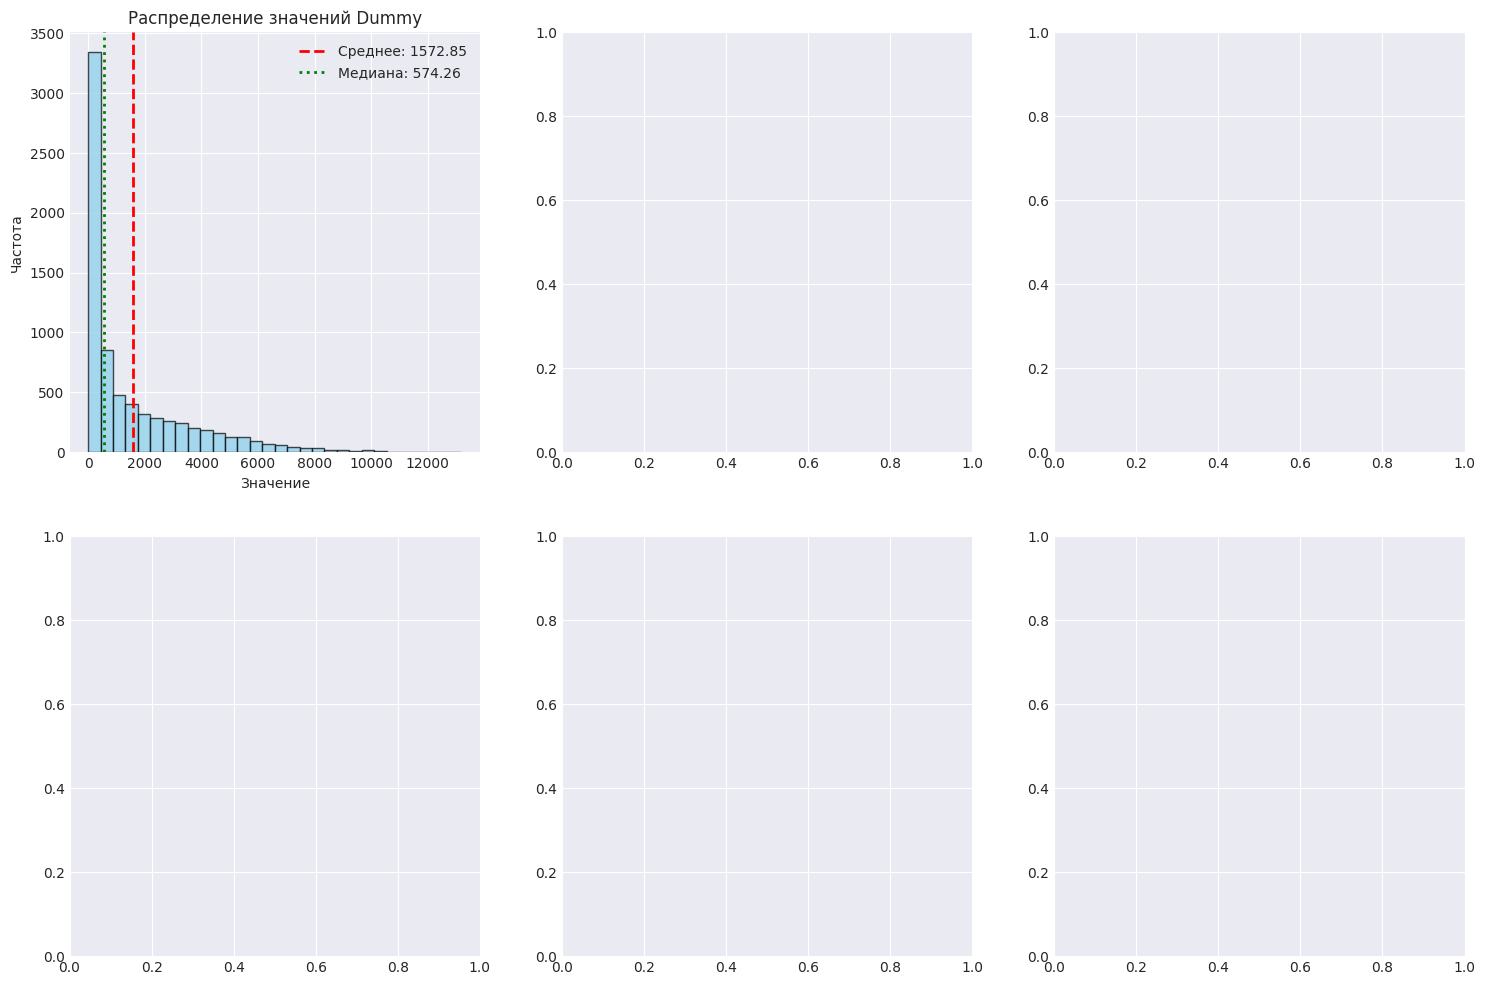

In [6]:

def analyze_algorithm(algorithm_name):
    if algorithm_name not in full_df.columns:
        print(f"Алгоритм {algorithm_name} не найден в данных")
        return

    print(f"=== АНАЛИЗ АЛГОРИТМА: {algorithm_name} ===")
    print("=" * 60)
    rel_col = f"{algorithm_name}_rel_to_Dummy"

    print(f"\nСТАТИСТИКА:")
    print("-" * 40)
    stats = full_df[algorithm_name].describe()
    for stat_name, stat_value in stats.items():
        print(f"  {stat_name}: {stat_value:.3f}")
    print(f"\nСТАТИСТИКА РЕКОРДОВ:")
    print("-" * 40)

    record_count = 0
    unique_record_count = 0

    algorithm_columns = [
        col
        for col in full_df.columns
        if col
        not in [
            "file_path",
            "filename",
            "seed",
            "cnt_tools",
            "interval_per_tool",
            "operation_density",
            "edge_density",
            "tool_on_operation_density",
            "min_interval_dur",
            "min_spacer_dur",
            "full_filename",
            "results_file",
            "best_algorithm",
            "best_value",
            "num_best_algorithms",
            "all_best_algorithms",
            "best_improvement_over_Dummy",
            "problem_size",
        ]
        and not col.startswith("_")
    ]
    algorithm_columns = algorithm_columns[:25]
    algorithm_columns = [
        col
        for col in algorithm_columns
        if full_df[col].dtype in ["float64", "int64"]
    ]

    for _, row in full_df.iterrows():
        algo_values = {}
        for algo in algorithm_columns:
            if algo in row and pd.notnull(row[algo]):
                algo_values[algo] = row[algo]

        if algo_values:
            best_value = min(algo_values.values())

            if (
                algorithm_name in algo_values
                and algo_values[algorithm_name] == best_value
            ):
                record_count += 1
                best_algos = [
                    algo for algo, val in algo_values.items() if val == best_value
                ]
                if len(best_algos) == 1:
                    unique_record_count += 1

    total_tasks = len(full_df)
    print(f"  Рекордов (с учетом совместных): {record_count}")
    print(f"  Процент задач с рекордом: {(record_count/total_tasks)*100:.1f}%")
    print(f"  Уникальных рекордов (единственный лучший): {unique_record_count}")
    print(
        f"  Процент уникальных рекордов: {(unique_record_count/total_tasks)*100:.1f}%"
    )

    if record_count > 0:
        print(f"\nХАРАКТЕРИСТИКИ ЗАДАЧ С РЕКОРДАМИ:")
        print("-" * 40)
        record_tasks = []
        for idx, row in full_df.iterrows():
            algo_values = {}
            for algo in algorithm_columns:
                if algo in row and pd.notnull(row[algo]):
                    algo_values[algo] = row[algo]

            if algo_values and algorithm_name in algo_values:
                best_value = min(algo_values.values())
                if algo_values[algorithm_name] == best_value:
                    record_tasks.append(row)

        if record_tasks:
            record_df = pd.DataFrame(record_tasks)
            if "cnt_tools" in record_df.columns:
                print(
                    f"  Среднее количество инструментов: {record_df['cnt_tools'].mean():.1f}"
                )
            if "interval_per_tool" in record_df.columns:
                print(
                    f"  Среднее количество интервалов: {record_df['interval_per_tool'].mean():.1f}"
                )
            if "operation_density" in record_df.columns:
                print(
                    f"  Средняя плотность операций: {record_df['operation_density'].mean():.3f}"
                )

    if rel_col in full_df.columns:
        print(f"\nОТНОСИТЕЛЬНАЯ ЭФФЕКТИВНОСТЬ ({algorithm_name} / Dummy):")
        print("-" * 40)

        rel_data = full_df[rel_col].dropna()
        print(f"  Среднее: {rel_data.mean():.3f}")
        print(f"  Медиана: {rel_data.median():.3f}")
        print(f"  Стандартное отклонение: {rel_data.std():.3f}")
        print(f"  Минимум: {rel_data.min():.3f}")
        print(f"  Максимум: {rel_data.max():.3f}")

        print(f"\n  Квартили:")
        print(f"    25%: {rel_data.quantile(0.25):.3f}")
        print(f"    50%: {rel_data.quantile(0.50):.3f}")
        print(f"    75%: {rel_data.quantile(0.75):.3f}")

    better_col = f"{algorithm_name}_better_than_Dummy"
    if better_col in full_df.columns:
        better_count = full_df[better_col].sum()
        better_percentage = (better_count / total_tasks) * 100
        worse_count = total_tasks - better_count

        print(f"\n СРАВНЕНИЕ С DUMMY:")
        print("-" * 40)
        print(
            f"  Лучше Dummy: {int(better_count)} задач ({better_percentage:.1f}%)"
        )
        print(
            f"  Хуже или равно Dummy: {int(worse_count)} задач ({100-better_percentage:.1f}%)"
        )

    print(f"\n КОРРЕЛЯЦИИ С ХАРАКТЕРИСТИКАМИ ЗАДАЧ:")
    print("-" * 40)

    feature_cols = [
        "cnt_tools",
        "interval_per_tool",
        "operation_density",
        "edge_density",
        "tool_on_operation_density",
    ]

    correlations = []
    for col in feature_cols:
        if col in full_df.columns:
            corr = full_df[algorithm_name].corr(full_df[col])
            correlations.append((col, corr))
            print(f"  {col}: {corr:.3f}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    ax1 = axes[0, 0]
    full_df[algorithm_name].hist(
        bins=30, ax=ax1, edgecolor="black", alpha=0.7, color="skyblue"
    )
    ax1.axvline(
        x=full_df[algorithm_name].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Среднее: {full_df[algorithm_name].mean():.2f}",
    )
    ax1.axvline(
        x=full_df[algorithm_name].median(),
        color="green",
        linestyle=":",
        linewidth=2,
        label=f"Медиана: {full_df[algorithm_name].median():.2f}",
    )
    ax1.set_title(f"Распределение значений {algorithm_name}")
    ax1.set_xlabel("Значение")
    ax1.set_ylabel("Частота")
    ax1.legend()

    ax2 = axes[0, 1]
    if rel_col in full_df.columns:
        full_df[rel_col].hist(
            bins=30, ax=ax2, edgecolor="black", alpha=0.7, color="lightgreen"
        )
        ax2.axvline(
            x=1, color="red", linestyle="--", linewidth=2, label="Равен Dummy"
        )
        ax2.axvline(
            x=full_df[rel_col].mean(),
            color="blue",
            linestyle="-",
            linewidth=2,
            label=f"Среднее: {full_df[rel_col].mean():.2f}",
        )
        ax2.set_title(f"Относительная эффективность (vs Dummy)")
        ax2.set_xlabel(f"{algorithm_name} / Dummy (меньше = лучше)")
        ax2.set_ylabel("Частота")
        ax2.legend()

    ax3 = axes[0, 2]
    if "cnt_tools" in full_df.columns and "interval_per_tool" in full_df.columns:
        full_df["problem_size"] = (
            full_df["cnt_tools"] * full_df["interval_per_tool"]
        )
        
        if record_tasks:
            record_df = pd.DataFrame(record_tasks)
            ax3.scatter(
                record_df["problem_size"],
                record_df[algorithm_name],
                alpha=0.7,
                s=50,
                c="gold",
                edgecolors="black",
                label="С рекордом",
                marker="*",
            )

        ax3.scatter(
            full_df["problem_size"],
            full_df[algorithm_name],
            alpha=0.4,
            s=20,
            c="blue",
            label="Все задачи",
        )

        z = np.polyfit(
            full_df["problem_size"].fillna(0), full_df[algorithm_name].fillna(0), 1
        )
        p = np.poly1d(z)
        x_trend = np.linspace(
            full_df["problem_size"].min(), full_df["problem_size"].max(), 50
        )
        ax3.plot(x_trend, p(x_trend), "r--", alpha=0.8, label="Тренд")

        ax3.set_title(f"{algorithm_name} vs размер задачи")
        ax3.set_xlabel("Размер задачи (m × n)")
        ax3.set_ylabel(f"Значение {algorithm_name}")
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
    ax4 = axes[1, 0]
    top_algos = []
    algo_records = {}

    for algo in algorithm_columns:  # Ограничим для производительности
        algo_records[algo] = 0
        for _, row in full_df.iterrows():
            algo_values = {}
            for a in algorithm_columns[:10]:
                if a in row and pd.notnull(row[a]):
                    algo_values[a] = row[a]
            if algo_values and algo in algo_values:
                best_val = min(algo_values.values())
                if algo_values[algo] == best_val:
                    algo_records[algo] += 1

    top_algos = sorted(algo_records.items(), key=lambda x: x[1], reverse=True)[:5]
    top_algo_names = [a[0] for a in top_algos]

    if algorithm_name in top_algo_names:
        boxplot_data = []
        for algo in top_algo_names:
            if algo in full_df.columns:
                boxplot_data.append(full_df[algo].dropna())

        if boxplot_data:
            bp = ax4.boxplot(boxplot_data, labels=top_algo_names, patch_artist=True)
            ax4.set_title("Сравнение с топ-5 алгоритмами")
            ax4.set_ylabel("Значение")
            ax4.tick_params(axis="x", rotation=45)
            current_idx = (
                top_algo_names.index(algorithm_name)
                if algorithm_name in top_algo_names
                else -1
            )
            if current_idx >= 0:
                bp["boxes"][current_idx].set_facecolor("gold")
            else:
                ax4.text(
                    0.5,
                    0.5,
                    "Алгоритм не в топ-5",
                    ha="center",
                    va="center",
                    transform=ax4.transAxes,
                )
    else:
        ax4.text(
            0.5,
            0.5,
            "Алгоритм не в топ-5 по рекордам",
            ha="center",
            va="center",
            transform=ax4.transAxes,
        )

    ax5 = axes[1, 1]
    corr_data = []
    corr_labels = []

    for col in feature_cols:
        if col in full_df.columns:
            corr_data.append(full_df[algorithm_name].corr(full_df[col]))
            corr_labels.append(col)

    if corr_data:
        colors = ["red" if x < 0 else "blue" for x in corr_data]
        bars = ax5.bar(range(len(corr_data)), corr_data, color=colors, alpha=0.7)
        ax5.set_xticks(range(len(corr_data)))
        ax5.set_xticklabels(corr_labels, rotation=45, ha="right")
        ax5.set_title("Корреляции с характеристиками задач")
        ax5.set_ylabel("Коэффициент корреляции")
        ax5.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
        ax5.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
        ax5.axhline(y=-0.5, color="gray", linestyle="--", alpha=0.5)

        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax5.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + (0.02 if height >= 0 else -0.05),
                f"{height:.2f}",
                ha="center",
                va="bottom" if height >= 0 else "top",
            )

    ax6 = axes[1, 2]
    if "cnt_tools" in full_df.columns and record_tasks:
        record_df = pd.DataFrame(record_tasks)
        all_by_m = full_df.groupby("cnt_tools").size()
        record_by_m = record_df.groupby("cnt_tools").size()
        tools_cnt = sorted(set(all_by_m.index) & set(record_by_m.index))
        percentages = [
            (record_by_m[m] / all_by_m[m]) * 100 if m in record_by_m.index else 0
            for m in tools_cnt
        ]

        if tools_cnt:
            ax6.bar(
                [str(m) for m in tools_cnt], percentages, color="purple", alpha=0.7
            )
            ax6.set_title("Процент рекордов по количеству инструментов")
            ax6.set_xlabel("Количество инструментов (m)")
            ax6.set_ylabel("Процент рекордов (%)")
            ax6.tick_params(axis="x", rotation=45)
        else:
            ax6.text(
                0.5,
                0.5,
                "Недостаточно данных",
                ha="center",
                va="center",
                transform=ax6.transAxes,
            )

    plt.tight_layout()
    plt.show()

    print(f"\nДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
    print("-" * 40)
    print(f"  Всего задач в анализе: {total_tasks}")
    print(f"  Пропущенных значений: {full_df[algorithm_name].isna().sum()}")

    print(f"\n  Топ-5 лучших результатов {algorithm_name}:")
    best_results = full_df.nsmallest(5, algorithm_name)[
        ["filename", algorithm_name, "best_improvement_over_Dummy"]
    ]
    for idx, row in best_results.iterrows():
        print(
            f"    {row['filename']}: {row[algorithm_name]:.3f} (улучшение: {row['best_improvement_over_Dummy']:.3f})"
        )

    print(f"\n  Топ-5 худших результатов {algorithm_name}:")
    worst_results = full_df.nlargest(5, algorithm_name)[
        ["filename", algorithm_name, "best_improvement_over_Dummy"]
    ]
    for idx, row in worst_results.iterrows():
        print(
            f"    {row['filename']}: {row[algorithm_name]:.3f} (улучшение: {row['best_improvement_over_Dummy']:.3f})"
        )

algorithm_columns = [
    col
    for col in full_df.columns
    if full_df[col].dtype in ["float64", "int64"]
    and col
    not in [
        "cnt_tools",
        "interval_per_tool",
        "operation_density",
        "edge_density",
        "tool_on_operation_density",
        "min_interval_dur",
        "min_spacer_dur",
        "best_improvement_over_Dummy",
        "num_best_algorithms",
    ]
    and not col.startswith("_")
]

algorithm_columns = algorithm_columns[:25]

if algorithm_columns:
    algorithm_selector = widgets.Dropdown(
        options=algorithm_columns,
        value=algorithm_columns[0] if algorithm_columns else None,
        description="Алгоритм:",
        disabled=False,
        style={"description_width": "initial"},
        layout={"width": "50%"},
    )

    print("\n" + "=" * 60)
    print("ДЕТАЛЬНЫЙ АНАЛИЗ АЛГОРИТМА")
    print("=" * 60)
    print("Выберите алгоритм из выпадающего списка для детального анализа:")

    interact(analyze_algorithm, algorithm_name=algorithm_selector)
else:
    print("Не найдено алгоритмов для анализа")

In [12]:
target_columns = []
for col in full_df.columns.to_list():
    if ("_rel_to_Dummy" in col or col == "file_path"):
        target_columns.append(col)


for_dataset = full_df[target_columns].copy()
for_dataset

,file_path,Directive_rel_to_Dummy,Stoppable_rel_to_Dummy,Robin_rel_to_Dummy,FineSorter_rel_to_Dummy,Dependent_rel_to_Dummy,MDummy6_2_rel_to_Dummy,MDirective6_2_rel_to_Dummy,MStoppable6_2_rel_to_Dummy,MRobin6_2_rel_to_Dummy,MFineSorter6_2_rel_to_Dummy,MDependent6_2_rel_to_Dummy,MDummy3_4_rel_to_Dummy,MDirective3_4_rel_to_Dummy,MStoppable3_4_rel_to_Dummy,MRobin3_4_rel_to_Dummy,MFineSorter3_4_rel_to_Dummy,MDependent3_4_rel_to_Dummy,MDummy2_8_rel_to_Dummy,MDirective2_8_rel_to_Dummy,MStoppable2_8_rel_to_Dummy,MRobin2_8_rel_to_Dummy,MFineSorter2_8_rel_to_Dummy,MDependent2_8_rel_to_Dummy,Aggregator_rel_to_Dummy
0,../../dataset_directory_big/45_20/2349008_45_2...,0.666859,1.000000,0.666859,0.666859,5.415926,1.203093,0.666859,0.666859,0.666859,0.666859,5.415926,2.308404,0.666859,1.772174,0.666859,0.666859,5.415926,0.666859,0.666859,0.666859,0.666859,0.666859,5.415926,1.203093
1,../../dataset_directory_big/45_20/2349008_45_2...,0.830022,1.038824,1.031864,0.860820,1.386333,1.065528,0.830022,0.639703,0.873970,0.860820,1.327993,0.733505,0.830022,0.733505,0.869779,0.860820,1.451895,0.860820,0.830022,0.767018,1.031086,0.860820,1.327993,0.860820
2,../../dataset_directory_big/45_20/2349008_45_2...,0.996969,1.000000,1.410912,0.941189,0.959776,1.000932,0.996969,0.941189,0.941189,0.941189,0.941189,1.406522,0.996969,0.941189,0.941189,0.941189,0.941189,0.996969,0.996969,0.941189,0.941189,0.941189,0.941189,0.941189
3,../../dataset_directory_big/45_20/2349008_45_2...,1.084209,0.956025,2.024644,1.224888,1.116915,1.306390,1.084209,0.856053,0.638884,1.224888,1.296305,1.106945,1.084209,1.001043,0.778077,1.224888,1.110394,1.149249,1.084209,0.990617,1.512697,1.224888,1.206414,1.031317
4,../../dataset_directory_big/45_20/2349008_45_2...,0.934630,1.171575,1.007413,0.964961,0.907216,0.878909,0.934630,1.006458,0.858121,0.964961,0.944952,0.879254,0.934630,0.926223,0.975012,0.964961,0.944952,0.879254,0.934630,0.919557,0.879254,0.964961,0.920301,0.852278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,../../dataset_directory_big/45_70/68123_45_70_...,0.942089,0.976889,1.150628,0.585297,1.090525,0.645266,0.942089,0.563890,0.813985,0.585297,1.088823,0.681030,0.942089,0.698579,0.856740,0.585297,1.239699,0.599253,0.942089,0.605415,1.084010,0.585297,1.139831,0.577985
8122,../../dataset_directory_big/45_70/68123_45_70_...,0.786685,0.861757,0.925940,0.758921,0.995289,0.646878,0.786685,0.685602,0.859975,0.758921,0.870498,0.729622,0.786685,0.633940,0.700355,0.758921,0.946893,0.758144,0.786685,0.713726,0.865074,0.758921,1.465582,0.623931
8123,../../dataset_directory_big/45_70/68123_45_70_...,1.211037,0.892898,0.877999,0.781850,0.974967,0.535484,1.211037,0.698348,0.816614,0.781850,0.867849,0.732729,1.211037,0.567157,0.800077,0.781850,0.979554,0.793186,1.211037,0.566939,1.090506,0.781850,0.896240,0.650785
8124,../../dataset_directory_big/45_70/68123_45_70_...,1.418627,0.925649,1.150967,0.932993,0.907390,0.856065,1.418627,0.752696,0.992567,0.932993,1.335395,0.790362,1.418627,0.663306,1.119048,0.932993,0.728674,0.987628,1.418627,0.835676,0.826982,0.932993,0.850087,1.033459


In [15]:
def inverse_softmax_with_temperature(x, temperature=0.05):
    x = np.array(x, dtype=float)
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    
    # Negate to invert (so lower original becomes higher)
    x_neg = -x
    
    # Apply temperature scaling
    x_scaled = x_neg / temperature
    
    # Stabilize by subtracting max
    x_stable = x_scaled - np.max(x_scaled)
    
    # Apply softmax
    exp_x = np.exp(x_stable)
    return exp_x / np.sum(exp_x)


df_inv = for_dataset.copy()
for idx in for_dataset.index:
    values = for_dataset.loc[idx, target_columns[1:]].values
    df_inv.loc[idx, target_columns[1:]] = inverse_softmax_with_temperature(values)
    
df_inv

,file_path,Directive_rel_to_Dummy,Stoppable_rel_to_Dummy,Robin_rel_to_Dummy,FineSorter_rel_to_Dummy,Dependent_rel_to_Dummy,MDummy6_2_rel_to_Dummy,MDirective6_2_rel_to_Dummy,MStoppable6_2_rel_to_Dummy,MRobin6_2_rel_to_Dummy,MFineSorter6_2_rel_to_Dummy,MDependent6_2_rel_to_Dummy,MDummy3_4_rel_to_Dummy,MDirective3_4_rel_to_Dummy,MStoppable3_4_rel_to_Dummy,MRobin3_4_rel_to_Dummy,MFineSorter3_4_rel_to_Dummy,MDependent3_4_rel_to_Dummy,MDummy2_8_rel_to_Dummy,MDirective2_8_rel_to_Dummy,MStoppable2_8_rel_to_Dummy,MRobin2_8_rel_to_Dummy,MFineSorter2_8_rel_to_Dummy,MDependent2_8_rel_to_Dummy,Aggregator_rel_to_Dummy
0,../../dataset_directory_big/45_20/2349008_45_2...,6.666079e-02,0.000085,6.666079e-02,0.066661,3.749719e-43,0.000001,6.666079e-02,0.066661,0.066661,0.066661,3.749719e-43,3.677882e-16,6.666079e-02,1.671988e-11,0.066661,0.066661,3.749719e-43,0.066661,6.666079e-02,0.066661,6.666079e-02,0.066661,3.749719e-43,0.000001
1,../../dataset_directory_big/45_20/2349008_45_2...,1.419150e-02,0.000218,2.505269e-04,0.007665,2.089159e-07,0.000128,1.419150e-02,0.638442,0.005893,0.007665,6.709718e-07,9.780616e-02,1.419150e-02,9.780616e-02,0.006408,0.007665,5.630028e-08,0.007665,1.419150e-02,0.050036,2.544528e-04,0.007665,6.709718e-07,0.007665
2,../../dataset_directory_big/45_20/2349008_45_2...,1.934641e-02,0.018208,4.910602e-06,0.059034,4.070526e-02,0.017872,1.934641e-02,0.059034,0.059034,0.059034,5.903370e-02,5.361240e-06,1.934641e-02,5.903370e-02,0.059034,0.059034,5.903370e-02,0.019346,1.934641e-02,0.059034,5.903370e-02,0.059034,5.903370e-02,0.059034
3,../../dataset_directory_big/45_20/2349008_45_2...,1.255392e-04,0.001630,8.516547e-13,0.000008,6.526682e-05,0.000001,1.255392e-04,0.012037,0.926440,0.000008,1.805235e-06,7.967023e-05,1.255392e-04,6.624459e-04,0.057254,0.000008,7.435949e-05,0.000034,1.255392e-04,0.000816,2.382184e-08,0.000008,1.089720e-05,0.000362
4,../../dataset_directory_big/45_20/2349008_45_2...,2.757122e-02,0.000241,6.430905e-03,0.015032,4.770617e-02,0.084032,2.757122e-02,0.006555,0.127352,0.015032,2.242872e-02,8.345509e-02,2.757122e-02,3.261990e-02,0.012294,0.015032,2.242872e-02,0.083455,2.757122e-02,0.037272,8.345509e-02,0.015032,3.672154e-02,0.143141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,../../dataset_directory_big/45_70/68123_45_70_...,9.162651e-05,0.000046,1.414721e-06,0.115101,4.706709e-06,0.034689,9.162651e-05,0.176610,0.001188,0.115101,4.869715e-06,1.696474e-02,9.162651e-05,1.194332e-02,0.000505,0.115101,2.382394e-07,0.087068,9.162651e-05,0.076972,5.361740e-06,0.115101,1.755711e-06,0.133226
8122,../../dataset_directory_big/45_70/68123_45_70_...,1.022137e-02,0.002277,6.308978e-04,0.017810,1.576147e-04,0.167439,1.022137e-02,0.077180,0.002360,0.017810,1.912141e-03,3.200042e-02,1.022137e-02,2.168877e-01,0.057460,0.017810,4.149174e-04,0.018089,1.022137e-02,0.043977,2.131228e-03,0.017810,1.296235e-08,0.264957
8123,../../dataset_directory_big/45_70/68123_45_70_...,5.975818e-07,0.000347,4.668010e-04,0.003194,6.712401e-05,0.440739,5.975818e-07,0.016965,0.001593,0.003194,5.718708e-04,8.529725e-03,5.975818e-07,2.339218e-01,0.002218,0.003194,6.124063e-05,0.002546,5.975818e-07,0.234944,6.657646e-06,0.003194,3.241130e-04,0.043923
8124,../../dataset_directory_big/45_70/68123_45_70_...,1.650707e-07,0.003160,3.487636e-05,0.002728,4.552186e-03,0.012706,1.650707e-07,0.100432,0.000829,0.002728,8.721989e-07,4.728321e-02,1.650707e-07,6.002089e-01,0.000066,0.002728,1.623786e-01,0.000915,1.650707e-07,0.019104,2.273166e-02,0.002728,1.431995e-02,0.000366


In [16]:
df_inv['file_path'] = df_inv['file_path'].str.replace('../../', '', regex=False)
df_inv.to_csv('labels.csv', index=False)